# Tabulated solar models: are you computing the observable?

Mag$\nu$s ships twelve standard solar models, from BP2000 to the B23 series, and the Sun
wrappers take any of them by name through `density_profile`; the default is an exponential
fit. This notebook works with one of them, **BS2005-AGS,OP** (Bahcall, Serenelli & Basu,
ApJ 621, L85), and uses it to separate two quantities that are easy to confuse:

* the **instantaneous** probability at one baseline, which is what `osc_prob_*` returns;
* the **phase-averaged** probability, which is what a solar-neutrino experiment measures.

They are different quantities, not two estimates of one quantity, and the notebook's
headline is about how you get the second.

**The tempting route does not work.** Averaging a scan of instantaneous probabilities over a
window of several oscillation lengths looks like the obvious way to reach the observable. On
a solar trajectory it is not: the answer sits several $10^{-3}$ from the averaged limit and
drifts by $2\times10^{-3}$ depending on how wide a window you pick, because widening the window
also averages over a changing density. The estimator has no converged value to offer.

**The direct route is exact.** `average=True` evaluates the phase-averaged limit in closed
form -- one matrix product, no scan -- and it reproduces the textbook adiabatic MSW
expression to **machine precision, 3e-16, across 1--20 MeV**, checked against a formula that
owes nothing to Mag$\nu$s.

The notebook also shows the diagnostics: `strategy_info['sampling']` for how coarsely a scan
resolves the oscillation it is sampling, and `avgprob.coherence_report` for whether the
averaged limit applies at all.

**Section 7 compares all twelve models** on the averaged observable. Its numbers are stored in
`solar_models_cache.json` and read back on every rebuild, so continuous integration does not
recompute them.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import magnus.globaldefs as gd

# Best-fit oscillation parameters from the latest global fit.
# load_nufit_params returns exactly the six parameters the
# osc_prob_3nu_* functions take, so it can be splatted straight in.
NUFIT_NO = gd.load_nufit_params('NuFIT 6.1', 'NO')
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.oscprob as oscprob
import magnus.adiabatic as adiabatic
import magnus.solarmodels as solarmodels

# The model this notebook works with, by the name the Sun wrappers take.
MODEL = 'BS05-AGS-OP'

plt.rcParams["figure.dpi"] = 110

## 1. The model, and what the package does with it

`magnus.solarmodels` reads the tables that ship with the package: three columns of each
authors' file, radius, mass density and hydrogen mass fraction, copied as written. A Sun
wrapper given `density_profile=MODEL` builds the electron density from them, and two
details in that are easy to get wrong:

* **The electron fraction is not 0.5.** For fully ionized H + He,
  $n_e = \rho\,N_A\,(1+X)/2$, and the hydrogen mass fraction $X$ runs from 0.36 at the
  center to 0.76 at the outer edge of the table. A fixed $Y_e = 0.5$ therefore understates
  $n_e$ by 37 % at the center and by 76 % at the edge, which is why we build the number
  density ourselves rather than handing a mass density to `vcc_func_from_rho_func` (that
  function takes a *scalar* electron fraction).
* **Interpolate in $\log n_e$.** The density spans five orders of magnitude; a linear
  interpolant in the raw value is poor and a spline can undershoot to negative values.

The cell below does the same by hand, and checks that it lands on the package's profile. That
is also how to use a table of your own: build $n_e(l)$ and hand it to a scenario function, as
the cubic spline of section 4 does.

In [3]:
print('models that ship:', ', '.join(solarmodels.available_solar_models()))
info = solarmodels.solar_model_info(MODEL)
print('%s: %s' % (MODEL, info['reference']))

table = solarmodels.load_solar_model(MODEL)
r_over_rsun = table['r_over_r_sun']
rho_cgs, x_hydrogen = table['rho_g_per_cm3'], table['x_hydrogen']

# n_e = rho * N_A * (1 + X) / 2, in the package's natural units [eV^3].
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
ne_ev3 = rho_cgs*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*(0.5*(1.0 + x_hydrogen))

x_nat = r_over_rsun*gd.SUN_RADIUS*gd.UNIT_KM          # radius in eV^-1
log_ne = np.log(ne_ev3)

def ne_bs05(l):
    '''Electron number density [eV^3] at position l [eV^-1], log-interpolated.'''
    xs = np.clip(np.asarray(l, dtype=float), x_nat[0], x_nat[-1])
    out = np.exp(np.interp(xs, x_nat, log_ne))
    return out[()] if np.ndim(out) == 0 else out

# The package's own profile.  Inside the table the two are the same function; outside it,
# the package holds the core value below the first row, as this does, and past the last row
# continues the last interval's slope rather than holding the edge value.
ne_package = solarmodels.electron_density_profile(MODEL)
inside = np.linspace(x_nat[0], x_nat[-1], 5001)
print('%d rows, r = %.5f .. %.5f R_sun' % (len(r_over_rsun), r_over_rsun[0], r_over_rsun[-1]))
print('central n_e = %.1f N_A cm^-3' % (ne_ev3[0]/gd.N_AV/gd.UNIT_PER_CM3))
print('hand-built profile equals the package\'s inside the table, bit for bit: %s'
      % np.array_equal(ne_bs05(inside), ne_package(inside)))

models that ship: BP2000, BP04, BS05-OP, BS05-AGS-OP, B16-GS98, B16-AGSS09met, B23-GS98, B23-AGSS09, B23-C11, B23-AAG21, B23-MB22m, B23-MB22p
BS05-AGS-OP: J. N. Bahcall, A. M. Serenelli and S. Basu, "New solar opacities, abundances, helioseismology, and neutrino fluxes", ApJ 621, L85 (2005), doi:10.1086/428929, astro-ph/0412440
1284 rows, r = 0.00161 .. 0.98308 R_sun
central n_e = 101.9 N_A cm^-3
hand-built profile equals the package's inside the table, bit for bit: True


### The package's exponential is a *fit*, not this model

`gd.NUM_DENSITY_E_SUN_CENTRAL` = 245 $N_A$ is the $r\to0$ intercept of the standard
exponential fit $n_e = 245\,N_A e^{-10.54 r/R_\odot}$, which the Sun wrappers use unless
`density_profile` names a model. The model's actual central value
is 101.9 $N_A$ (printed below). The fit is a few-percent description only between about
$0.2$ and $0.3\,R_\odot$; at $0.05\,R_\odot$ it is 1.6 times the model, and at the center
2.4 times.

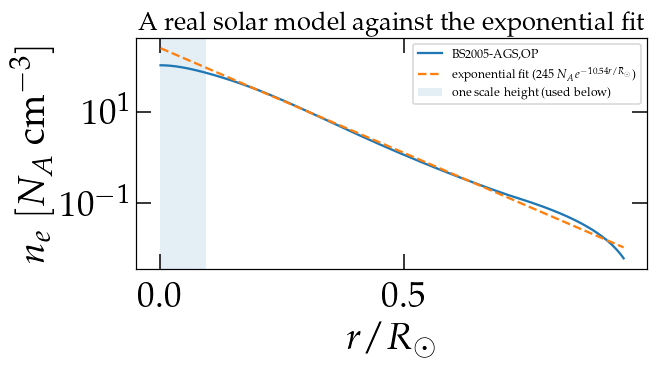

In [4]:
fit = matter.exp_density_profile(gd.NUM_DENSITY_E_SUN_CENTRAL, gd.L_SCALE_SUN)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
rr = np.linspace(0.002, 0.95, 400)
xs = rr*gd.SUN_RADIUS*gd.UNIT_KM
ax.semilogy(rr, np.asarray(ne_bs05(xs))/gd.N_AV/gd.UNIT_PER_CM3, label='BS2005-AGS,OP')
ax.semilogy(rr, np.asarray(fit(xs))/gd.N_AV/gd.UNIT_PER_CM3, '--',
            label=r'exponential fit ($245\,N_A e^{-10.54 r/R_\odot}$)')
ax.axvspan(0.0, gd.L_SCALE_SUN/(gd.SUN_RADIUS*gd.UNIT_KM), alpha=0.12,
           label='one scale height (used below)')
ax.set_xlabel(r'$r / R_\odot$'); ax.set_ylabel(r'$n_e\ [N_A\ {\rm cm}^{-3}]$')
ax.legend(fontsize=8); ax.set_title('A real solar model against the exponential fit')
fig.tight_layout()

## 2. The instantaneous probability, and its error

We take a two-flavor calculation at **5 MeV** -- in the $^8$B range -- over one solar
scale height, and check it against a tight-tolerance `solve_ivp` ground truth.  The call is
the two-flavor Sun wrapper with the model named; the ground truth integrates the same
profile, built by hand above.

In [5]:
def exact_U_many(H_func, l0, Ls, dim):
    '''Ground truth at many baselines from ONE integration.'''
    def rhs(l, y):
        return (-1j*np.asarray(H_func(l)) @ y.reshape(dim, dim)).ravel()
    sol = solve_ivp(rhs, (float(l0), float(Ls[-1])), np.eye(dim, dtype=complex).ravel(),
                    rtol=1e-12, atol=1e-14, method='DOP853', t_eval=Ls)
    return np.array([sol.y[:, i].reshape(dim, dim) for i in range(len(Ls))])

def to_P(U):
    return np.swapaxes(np.asarray(U).real**2 + np.asarray(U).imag**2, -1, -2)

ENERGY = 5.0*gd.UNIT_MEV
L0, L1 = 0.0, gd.L_SCALE_SUN
params2 = {'sth': NUFIT_NO['s12'], 'Dm2': NUFIT_NO['D21']}

hvac2 = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(
    params2['sth'], params2['Dm2'])
e00 = np.diag([1.0, 0.0])
VCC = matter.vcc_func_from_rho_func(
    ne_bs05, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
    density_is_of_number_of_electrons=True)

def H_of_l(l):
    return (1.0/ENERGY)*hvac2 + np.asarray(VCC(l))[..., None, None]*e00

info = {}
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    P = np.asarray(oscprob.osc_prob_2nu_sun(
        ENERGY, L1, L0, **params2, density_profile=MODEL, strategy_info=info))
    raised = sorted({w.category.__name__ for w in caught})

P_ref = to_P(exact_U_many(H_of_l, L0, np.array([L1]), 2)[0])
print('engine        : %s' % info['engine'])
print('certified     : %s' % info.get('certified'))
print('warnings      : %s' % (', '.join(raised) or 'NONE'))
print('P_ee          : %.6f   (truth %.6f)' % (P[0][0], P_ref[0][0]))
print('max |error|   : %.3e   against a requested %.0e' % (np.max(np.abs(P - P_ref)), 1e-3))
print()
# A tolerance is a stopping rule: the refinement stops when two successive levels agree to
# it.  Asking for less makes it go further.
for tol in (1e-4, 1e-5):
    with warnings.catch_warnings(record=True) as caught_tol:
        warnings.simplefilter('always')
        P_tol = np.asarray(oscprob.osc_prob_2nu_sun(
            ENERGY, L1, L0, **params2, density_profile=MODEL, rtol=tol, atol=tol))
    print('rtol = atol = %.0e: max |error| %.3e  (%s)'
          % (tol, np.max(np.abs(P_tol - P_ref)),
             ', '.join(sorted({w.category.__name__ for w in caught_tol})) or 'no warning'))

engine        : hybrid
certified     : True
warnings      : NONE
P_ee          : 0.235268   (truth 0.236972)
max |error|   : 1.704e-03   against a requested 1e-03



rtol = atol = 1e-04: max |error| 8.706e-05  (MagnusConvergenceWarning)


rtol = atol = 1e-05: max |error| 1.945e-06  (MagnusConvergenceWarning)


The error is 1.7 times the tolerance asked for, and the result is reported `certified`,
with no warning. That is what a tolerance means here: it is a stopping rule rather than a
bound, and `certified` says that two successive refinements agreed to it, not that the answer
lies within it of the truth (the `rtol` entry of `osc_prob` says what it does and does not
promise). Asking for $10^{-4}$ brings the error to $9\times10^{-5}$, and $10^{-5}$ to
$2\times10^{-6}$. Both are answered by the slab ladder, and both raise
`MagnusConvergenceWarning`, which reports the width of a slab rather than an error.

That settles the accuracy, but not the interesting question, which is what this number is
*of*: it is the probability at **one exact baseline**, and no solar experiment measures that.

The rest of this notebook is about the quantity one does measure, and about how easy it is
to compute something that looks like it and is not.

## 3. `strategy_info['sampling']`: how much phase is in there?

`adiabatic.oscillation_sampling` reports how coarsely a request samples the oscillation
it is computing. It is surfaced through `strategy_info` and is computed **only** when you
ask for it, so it costs nothing on an ordinary call.

In [6]:
Ls_scan = np.linspace(0.2*L1, L1, 8)
info_scan = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    oscprob.osc_prob_2nu_sun(
        ENERGY, Ls_scan, L0, **params2, density_profile=MODEL, strategy_info=info_scan)

for k, v in sorted(info_scan['sampling'].items()):
    print('%-24s %s' % (k, ('%.4e' % v) if isinstance(v, float) else v))

aliased                  True
cycles_over_trajectory   4.5308e+02
cycles_per_step          5.1781e+01
nyquist_points           908
oscillation_length       7.3827e+11
spacing                  3.8228e+13


`cycles_per_step` is the number to read. Nyquist asks for two samples per oscillation, so
anything above 0.5 aliases; this eight-point scan sits at 52, which is **one sample every
fifty-two oscillations**. The individual values are correct, but the curve through them is
an artifact. `nyquist_points` says how many baselines would sample the oscillation
properly -- about 900 here, and several thousand at the energies and flavor counts used
elsewhere in the documentation.

That is the signature of a quantity dominated by phase. A solar-neutrino experiment
resolves none of it: the $^8$B production region is extended, the Sun-Earth path is
$\sim10^6$ oscillations at 5 MeV, and detector energy resolution finishes the job.

## 4. The averaged probability -- the quantity that is actually observed

A solar experiment measures the **phase-averaged** survival probability. The obvious way to
get at it is to average a scan of instantaneous probabilities over a window of several
oscillation lengths, and that is what this section does first -- because it is the natural
thing to try, it is what an earlier version of this notebook reported, and **it does not
work here.** The section after it shows the quantity that does.

In [7]:
L_OSC = 4.0*np.pi*ENERGY/params2['Dm2']         # vacuum oscillation length
Ls = np.linspace(L1 - 6.0*L_OSC, L1, 121)

P_ref_many = np.array([to_P(U) for U in exact_U_many(H_of_l, L0, Ls, 2)])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    P_pkg = np.array([np.asarray(oscprob.osc_prob_2nu_sun(
        ENERGY, float(L), L0, **params2, density_profile=MODEL)) for L in Ls])

err_inst = np.max(np.abs(P_pkg[-1] - P_ref_many[-1]))
err_avg = np.max(np.abs(P_pkg.mean(axis=0) - P_ref_many.mean(axis=0)))

print('trajectory        : %.0f oscillation lengths' % ((L1 - L0)/L_OSC))
# The verdicts are COMPUTED, not written into the format string.  They used to be
# asserted -- '<-- outside 1e-3' was a literal -- and when the underlying numbers
# moved the cell went on printing a verdict its own output contradicted.  A label
# that cannot be wrong by construction is worth more than a tidy one.
def _verdict(err, tol=1.0e-3):
    return ('outside' if err > tol else 'inside') + ' %.0e' % tol

print('instantaneous err : %.3e   <-- %s' % (err_inst, _verdict(err_inst)))
print('AVERAGED err      : %.3e   <-- %s' % (err_avg, _verdict(err_avg)))
print('averaging changes the error by %.2fx  (%s)'
      % (err_inst/err_avg,
         'helps' if err_avg < err_inst else 'does not help here -- see below'))
print()
print('averaged P_ee: package %.6f   truth %.6f' %
      (P_pkg.mean(axis=0)[0][0], P_ref_many.mean(axis=0)[0][0]))

trajectory        : 401 oscillation lengths
instantaneous err : 1.704e-03   <-- outside 1e-03
AVERAGED err      : 5.724e-04   <-- inside 1e-03
averaging changes the error by 2.98x  (helps)

averaged P_ee: package 0.599324   truth 0.599896


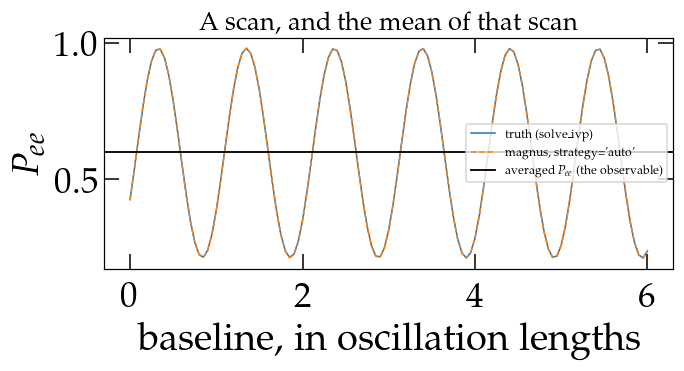

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
xs_plot = (Ls - Ls[0])/L_OSC
ax.plot(xs_plot, P_ref_many[:, 0, 0], lw=1.0, label='truth (solve_ivp)')
ax.plot(xs_plot, P_pkg[:, 0, 0], lw=1.0, ls='--', label="magnus, strategy='auto'")
ax.axhline(P_ref_many[:, 0, 0].mean(), color='k', lw=1.2,
           label='averaged $P_{ee}$ (the observable)')
ax.set_xlabel('baseline, in oscillation lengths'); ax.set_ylabel(r'$P_{ee}$')
ax.legend(fontsize=8); ax.set_title('A scan, and the mean of that scan')
fig.tight_layout()

Averaging brings the package closer to the ground truth, by a factor of three. But that
compares two estimates of the same scan mean, and the question is whether **the scan mean is
the observable**. It is not: it is not a converged estimate of anything.

Two things are wrong with it. The window is six *vacuum* oscillation lengths, but the
neutrino is in matter, so the window is not a whole number of actual cycles. And -- the
part that cannot be tuned away -- widening the window does not fix it, because a wider
window also averages over a **changing density**, and the averaged probability depends on
the local density. There is no window width that separates phase from the profile.

The truth alone shows this, no package involved: one ODE solve, several window widths.

In [9]:
# Truth only.  One integration with many output points, so this is cheap: the
# expensive thing in the cell above was one full ray propagation per baseline.
print('%-22s %s' % ('window', 'mean of the truth'))
print('-'*44)
for n_osc in (6, 12, 24, 48):
    Ls_w = np.linspace(L1 - n_osc*L_OSC, L1, 20*n_osc + 1)
    P_w = np.array([to_P(U) for U in exact_U_many(H_of_l, L0, Ls_w, 2)])
    print('%-22s %.6f' % ('%d oscillation lengths' % n_osc, P_w[:, 0, 0].mean()))

window                 mean of the truth
--------------------------------------------


6 oscillation lengths  0.599896


12 oscillation lengths 0.600095


24 oscillation lengths 0.599181


48 oscillation lengths 0.601426


The number moves by $2\times10^{-3}$ across the four windows, and the widest window leaves it
further from the averaged limit computed below, 0.5953, than the narrowest: 0.0061 against
0.0046. An estimator that does not settle as its window widens has a bias that is not
statistical.

### The averaged probability, computed rather than estimated

`average=True` evaluates the phase-averaged limit in closed form -- one matrix product, no
scan, no window. And it can be checked against something outside Mag$\nu$s entirely: for two
flavors on an adiabatic trajectory the averaged survival probability is the textbook MSW
expression

$$\langle P_{ee}\rangle = \frac{1}{2}
  + \frac{1}{2}\cos 2\theta_m(L_0)\,\cos 2\theta_m(L_1),$$

with $\theta_m$ the matter mixing angle at each end. Both ends are evaluated **in matter**:
this trajectory stops one scale height in, not in vacuum, so the usual $\cos 2\theta_{\rm vac}$
at the far end would be the wrong reference. The LMA solar crossing is never sharp, which is
what makes the adiabatic form exact here rather than approximate -- notebook 12 measures that
directly.

In [10]:
TH_VAC = np.arcsin(params2['sth'])

def cos2theta_matter(l, energy):
    """cos(2 theta_m): the two-flavor matter mixing angle at position l."""
    x = 2.0*energy*float(np.asarray(VCC(l)))/params2['Dm2']
    return np.cos(np.arctan2(np.sin(2.0*TH_VAC), np.cos(2.0*TH_VAC) - x))

def adiabatic_averaged(energy):
    """The closed-form averaged P_ee, both ends in matter."""
    return 0.5 + 0.5*cos2theta_matter(L0, energy)*cos2theta_matter(L1, energy)

print('%-10s %-16s %-16s %s' % ('E [MeV]', 'average=True', 'adiabatic', '|difference|'))
print('-'*60)
worst = 0.0
for E_mev in (1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0):
    E_here = E_mev*gd.UNIT_MEV
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        got = np.asarray(oscprob.osc_prob_2nu_sun(
            E_here, L1, L0, **params2, density_profile=MODEL, average=True))[0][0]
    want = adiabatic_averaged(E_here)
    worst = max(worst, abs(got - want))
    print('%-10.1f %-16.8f %-16.8f %.2e' % (E_mev, got, want, abs(got - want)))
print()
print('worst disagreement across the 8B range: %.2e' % worst)

E [MeV]    average=True     adiabatic        |difference|
------------------------------------------------------------
1.0        0.52362374       0.52362374       0.00e+00
2.0        0.49825104       0.49825104       5.55e-17
5.0        0.59528476       0.59528476       1.11e-16
8.0        0.75444863       0.75444863       2.22e-16


10.0       0.82639388       0.82639388       3.33e-16
15.0       0.91794450       0.91794450       2.22e-16
20.0       0.95411043       0.95411043       2.22e-16

worst disagreement across the 8B range: 3.33e-16


Machine precision, across the whole $^8$B range. That is the averaged solar
probability, and it is exact.

Compare the two routes on the same quantity at 5 MeV: the scan mean sat $4\times10^{-3}$ to
$6\times10^{-3}$ above the averaged limit and moved by $2\times10^{-3}$ with the width of its
window, while `average=True` reproduces an independent closed form to $10^{-16}$ at a
fraction of the cost. **If the averaged probability is what you want, ask for it; do not estimate it by
averaging a scan.** The scan is for looking at the oscillation, not for integrating it.

### Nor is the scan's behavior an artifact of the interpolation

A cubic spline through the same table (still in $\log n_e$) is a different profile, so it is
a fair second opinion on the scan-mean estimator.  It is also a profile of our own rather than
one the package ships, so it goes through the scenario function, which takes any callable.
It gives different numbers in both columns and the same picture: averaging brings the package
closer to the ground truth by a factor of two to three either way, and neither column is
about the observable. The failure of the window mean is a property of the estimator rather
than of one particular interpolant.

In [11]:
from scipy.interpolate import CubicSpline

_cs = CubicSpline(x_nat, log_ne, extrapolate=True)

def ne_bs05_cubic(l):
    xs = np.clip(np.asarray(l, dtype=float), x_nat[0], x_nat[-1])
    out = np.exp(_cs(xs))
    return out[()] if np.ndim(out) == 0 else out

VCC_c = matter.vcc_func_from_rho_func(
    ne_bs05_cubic, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
    density_is_of_number_of_electrons=True)

def H_cubic(l):
    return (1.0/ENERGY)*hvac2 + np.asarray(VCC_c(l))[..., None, None]*e00

ref_c = np.array([to_P(U) for U in exact_U_many(H_cubic, L0, Ls, 2)])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    got_c = np.array([np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05_cubic, ENERGY, float(L), params2, L0=L0,
        density_is_of_number_of_electrons=True)) for L in Ls])

ic = np.max(np.abs(got_c[-1] - ref_c[-1]))
ac = np.max(np.abs(got_c.mean(axis=0) - ref_c.mean(axis=0)))
# %.2f, not %.0f: a reduction of 0.85x printed as "1x" reads as "averaging left it
# alone" when what happened is that averaging made it slightly worse.  Two decimals
# is the difference between a number and a rounding artifact.
print('%-10s %12s %12s %10s' % ('interpolant', 'instant.', 'averaged', 'reduction'))
print('%-10s %12.3e %12.3e %9.2fx' % ('linear', err_inst, err_avg, err_inst/err_avg))
print('%-10s %12.3e %12.3e %9.2fx' % ('cubic', ic, ac, ic/ac))

interpolant     instant.     averaged  reduction
linear        1.704e-03    5.724e-04      2.98x
cubic         1.702e-03    7.651e-04      2.22x


## 5. When is the averaged limit the right limit?

Section 4 used `average=True` on the strength of the trajectory being adiabatic and the
phase being unresolvable. Neither is something to assume. `avgprob.coherence_report` checks
the second directly: it reports which pairs of eigenvalues have genuinely decohered over the
baseline, and which sit in the middle regime where **neither** the oscillating nor the
averaged expression is right.

In [12]:
import magnus.avgprob as avgprob

lam = np.linalg.eigvalsh(np.asarray(H_of_l(0.5*L1)))
blocks, undecided = avgprob.coherence_report(lam, phase_scale=L1)
print('coherence blocks :', blocks)
print('pairs in neither limit:', undecided or 'none -- the averaged expression is exact here')

coherence blocks : [[0], [1]]
pairs in neither limit: none -- the averaged expression is exact here


## Summary

| | |
|---|---|
| instantaneous error at 5 MeV | 1.7e-3 against a requested 1e-3, `certified`, no warning: a tolerance is a stopping rule, not a bound, and 1e-4 brings it to 9e-5. And it is the error at *one baseline*, which no solar experiment measures |
| averaging a scan to get the observable | **does not work here.** The mean sits $4$--$6\times10^{-3}$ above the averaged limit and drifts by $2\times10^{-3}$ with the window width, because a wider window also averages over changing density |
| the averaged probability, done properly | `average=True` -- closed form, one matrix product, and it matches the adiabatic MSW expression to $10^{-16}$ across 1--20 MeV |
| how to check the limit applies | `avgprob.coherence_report`, and `strategy_info['sampling']` for how coarsely a scan resolves the oscillation |

The lesson is not that a large instantaneous error is harmless -- it is that the
instantaneous probability and the averaged probability are **different quantities**, and
that estimating the second from a scan of the first is a numerical method with its own
error, which here is larger than anything it was meant to diagnose.

See the [Phase-Averaged Probabilities](https://mbustama.github.io/Magnus/averaged_probability.html)
page of the documentation for the full treatment, and notebook 14
for a profile where the averaged observable is genuinely wrong -- a sharp shock front, where
the error is in the envelope and no amount of averaging touches it.

## 6. Two BSM scenarios on the same model

Everything above is two-flavor and runs to one scale length. The two sections that follow
change three things at once, deliberately, and it is worth saying which:

* **Three flavors**, because NSI and a sterile state are both defined against the
  three-flavor picture.
* **The whole ray**, center to surface, because the averaged survival probability is a
  property of the full path.
* **`average=True`**, because that is the observable -- notebook 25 section 10 measures what
  recovering it from instantaneous evaluations costs another code, and the answer is a
  Monte-Carlo estimate at $1/\sqrt{N}$.

**In both sections the standard three-flavor curve is drawn alongside.** A BSM curve on its
own says nothing about size, and size is the only thing worth reading off these panels.

In [13]:
OSC3_BSM = dict(NUFIT_NO)
R_SUN_BSM = solarmodels.table_edge(MODEL)       # the last tabulated radius, 0.983 R_sun
E_BSM = np.logspace(np.log10(0.1), np.log10(20.0), 40)*gd.UNIT_MEV
# Everything the averaged calls below share: the model by name, from the center to the
# edge of its table, nu_e to nu_e.
SUN_BSM = dict(nu_i=gd.NUE, nu_f=gd.NUE, density_profile=MODEL, average=True)


def averaged_3nu(**kw):
    return np.asarray(oscprob.osc_prob_3nu_sun(
        E_BSM, R_SUN_BSM, 0.0, **OSC3_BSM, **SUN_BSM, **kw))


t0 = time.perf_counter()
P_std_bsm = averaged_3nu()
t_std_bsm = time.perf_counter() - t0
print('standard 3nu, %d averaged energies over the full ray: %.3f s'
      % (len(E_BSM), t_std_bsm))
print('  <P_ee> runs %.4f (low energy) -> %.4f (high energy)'
      % (P_std_bsm[0], P_std_bsm[-1]))

standard 3nu, 40 averaged energies over the full ray: 0.867 s
  <P_ee> runs 0.5449 (low energy) -> 0.2993 (high energy)


### 6.1 Non-standard interactions

NSI adds $\varepsilon$ to the matter matrix: $V_{\rm CC}(\mathrm{diag}(1,0,0) + \varepsilon)$,
with $\varepsilon$ dimensionless. Mag$\nu$s offers NSI wrappers at two, three, four and five
flavors alike, so "NSI at 3+1" can be asked for; we stay at three flavors here because the
sterile case is treated separately in 6.2 below.

**One check first.** `average=True` can be served either by the adiabatic route or by a
numerical window over an explicitly propagated probability, and those are *different
quantities* --- the $L/E\to\infty$ limit against an average over a finite spread. Which one the
NSI wrapper reaches is checked by its cost: the adiabatic route never propagates.

In [14]:
EPS_BSM = dict(eps_ee=0.15, eps_em=0.05, eps_et=0.0,
               eps_mm=0.0, eps_mt=0.0, eps_tt=0.0)

t0 = time.perf_counter()
P_nsi_bsm = np.asarray(oscprob.osc_prob_3nu_sun_nsi(
    E_BSM, R_SUN_BSM, 0.0, **OSC3_BSM, **EPS_BSM, **SUN_BSM))
t_nsi_bsm = time.perf_counter() - t0

# The verdict is computed from the timings rather than written into the format string, so
# that a loaded machine cannot make it print a claim its own numbers contradict.
print('WHICH ROUTE? standard %.3f s, NSI %.3f s -- %s.'
      % (t_std_bsm, t_nsi_bsm,
         'seconds, not minutes, so both adiabatic' if max(t_std_bsm, t_nsi_bsm) < 60.0
         else 'MINUTES: one of them may have taken the numerical route'))
print('A numerical window over this ray propagates a ~13 000 radian phase and costs')
print('minutes, so the timing is what distinguishes them.')
print()
print('eps = %s' % {k: v for k, v in EPS_BSM.items() if v})
print('departure from the standard curve: max %.4f at %.2f MeV, mean %.4f'
      % (np.max(np.abs(P_nsi_bsm - P_std_bsm)),
         E_BSM[int(np.argmax(np.abs(P_nsi_bsm - P_std_bsm)))]/gd.UNIT_MEV,
         np.mean(np.abs(P_nsi_bsm - P_std_bsm))))

WHICH ROUTE? standard 0.867 s, NSI 0.853 s -- seconds, not minutes, so both adiabatic.
A numerical window over this ray propagates a ~13 000 radian phase and costs
minutes, so the timing is what distinguishes them.

eps = {'eps_ee': 0.15, 'eps_em': 0.05}
departure from the standard curve: max 0.0143 at 2.99 MeV, mean 0.0053


### 6.2 A sterile state

3+1 changes the matter term as well as the mixing, and that is the part most easily got wrong.
The active flavors share the neutral-current potential $V_{\rm NC}$ and it cancels; a **sterile
state feels neither current**, so once the actives' common piece is removed it carries
$-V_{\rm NC} = (r/2)\,V_{\rm CC}$ with $r = n_n/n_p$. The projector is
$\mathrm{diag}(1, 0, 0, r/2)$, and it comes from `matter.matter_potential_projector` rather than
being written out --- writing it out is exactly how notebook 25's own PREM referee was wrong by
$2.6\times10^{-2}$ until recently.

The Sun wrappers take $r$ from the model: $(1 - X)/(1 + X)$ at each radius, from 0.47 at the
center of this table to 0.14 at its edge. An explicit `ratio_number_neutrons_to_protons`, a
number or a function of position, overrides it.

**So the check that matters is whether that entry is live**, and it is easy: vary $r$ and watch
the curve move. If the term were missing, the rows below would be identical. The last row is
the model's own composition, which is what the curves below use.

In [15]:
STERILE_BSM = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0,
                   d14=0.0, d24=0.0, D41=1.0e-5)
OSC4_BSM = dict(OSC3_BSM, **STERILE_BSM)


def averaged_4nu(ratio=None, energies=None):
    # ratio=None is the wrapper's default: n_n/n_p from the model, radius by radius.
    return np.asarray(oscprob.osc_prob_4nu_sun(
        E_BSM if energies is None else energies, R_SUN_BSM, 0.0, **OSC4_BSM,
        ratio_number_neutrons_to_protons=ratio, **SUN_BSM))


t0 = time.perf_counter()
P_ster_bsm = averaged_4nu()
t_ster_bsm = time.perf_counter() - t0
print('3+1, %d averaged energies: %.3f s  (the adiabatic route reaches four flavors)'
      % (len(E_BSM), t_ster_bsm))
print()
print('IS THE STERILE NEUTRAL-CURRENT ENTRY LIVE?  <P_ee> at 1, 5, 15 MeV:')
E_PROBE_BSM = np.array([1.0, 5.0, 15.0])*gd.UNIT_MEV
for ratio in (0.5, 1.0, 1.5, None):
    print('   n_n/n_p = %-11s ->  %s'
          % ('the model\'s' if ratio is None else '%.1f' % ratio,
             np.array2string(averaged_4nu(ratio, E_PROBE_BSM).ravel(), precision=6)))
print('   The curve moves, so the sterile state is feeling the medium.')
print()
print('departure from the standard curve: max %.4f at %.2f MeV, mean %.4f'
      % (np.max(np.abs(P_ster_bsm - P_std_bsm)),
         E_BSM[int(np.argmax(np.abs(P_ster_bsm - P_std_bsm)))]/gd.UNIT_MEV,
         np.mean(np.abs(P_ster_bsm - P_std_bsm))))

3+1, 40 averaged energies: 2.299 s  (the adiabatic route reaches four flavors)

IS THE STERILE NEUTRAL-CURRENT ENTRY LIVE?  <P_ee> at 1, 5, 15 MeV:
   n_n/n_p = 0.5         ->  [0.308682 0.242712 0.26625 ]


   n_n/n_p = 1.0         ->  [0.347954 0.262929 0.266994]
   n_n/n_p = 1.5         ->  [0.371761 0.267483 0.260167]


   n_n/n_p = the model's ->  [0.305303 0.241246 0.26595 ]
   The curve moves, so the sterile state is feeling the medium.

departure from the standard curve: max 0.2424 at 1.73 MeV, mean 0.1384


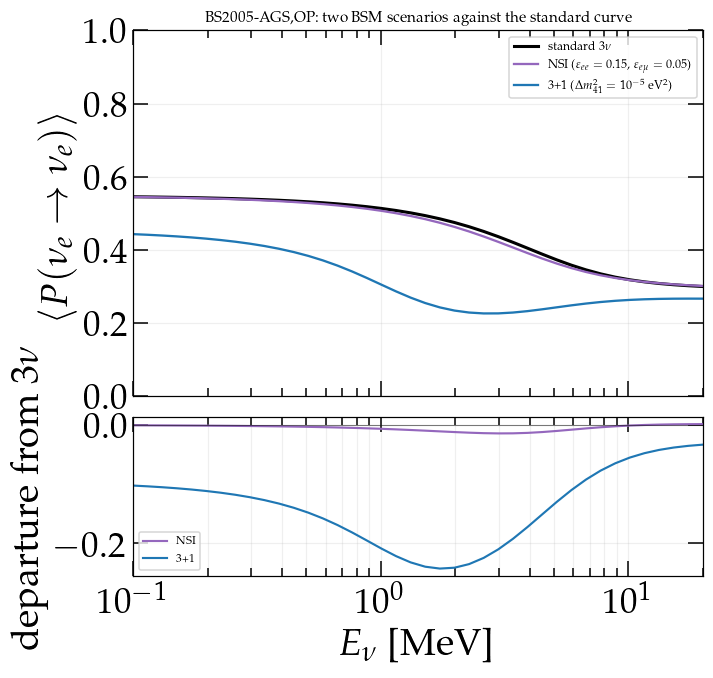

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(6.6, 6.0), sharex=True,
                       gridspec_kw=dict(height_ratios=[2.3, 1.0], hspace=0.08))
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_std_bsm, lw=2.0, color='k',
               label=r'standard 3$\nu$')
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_nsi_bsm, lw=1.5, color='C4',
               label=r'NSI  ($\varepsilon_{ee}=0.15$, $\varepsilon_{e\mu}=0.05$)')
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_ster_bsm, lw=1.5, color='C0',
               label=r'3+1  ($\Delta m^2_{41} = 10^{-5}$ eV$^2$)')
ax[0].set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$')
ax[0].set_title('BS2005-AGS,OP: two BSM scenarios against the standard curve',
                fontsize=10)
ax[0].grid(True, alpha=0.2)
ax[0].legend(fontsize=8)
ax[0].set_ylim(0.0, 1.0)

ax[1].semilogx(E_BSM/gd.UNIT_MEV, P_nsi_bsm - P_std_bsm, lw=1.4, color='C4',
               label='NSI')
ax[1].semilogx(E_BSM/gd.UNIT_MEV, P_ster_bsm - P_std_bsm, lw=1.4, color='C0',
               label='3+1')
ax[1].axhline(0.0, color='k', lw=0.7, alpha=0.5)
ax[1].set_xlabel(r'$E_\nu$ [MeV]')
ax[1].set_ylabel(r'departure from 3$\nu$')
ax[1].grid(True, which='both', alpha=0.2)
ax[1].legend(fontsize=7.6)
for a in ax:
    a.set_xlim(E_BSM[0]/gd.UNIT_MEV, E_BSM[-1]/gd.UNIT_MEV)
fig.savefig('../fig/solar_bsm.pdf', bbox_inches='tight')

**Where each effect lives is as informative as how big it is.** The sterile
departure is concentrated near the MSW transition, because that is where the extra level
crossing sits and where an additional state can rearrange which vacuum eigenstate the neutrino
emerges as. The NSI departure is broader and smaller: with these $\varepsilon$ it shifts the
resonance position rather than adding structure.

**And both are much smaller here than the same physics produces on a supernova shock.** The
identical $\varepsilon$ moves notebook 14's shock probability by 0.10 on average, twenty
times what it moves this one. The reason is the observable rather than the model: this
panel is **phase-averaged**, so everything entering through the phase integrates away and only
the change in the eigenvectors and level crossings survives. On the shock the quantity is an
instantaneous probability along a ray, and the phase term is the larger part of the effect.

That is worth carrying away from this notebook: **a BSM effect's size is a property of the
observable at least as much as of the model**, and a sensitivity estimate quoted without saying
which probability it refers to can be wrong by a factor of twenty.

## 7. All twelve models

Everything above used one table. The Sun wrappers take any of the twelve by name, so the
question of how much the choice matters costs one loop. This section asks it of the averaged
observable, at three flavors and with the 3+1 state of section 6.2, from the center to the
solar surface.

Two things to know about the tables first. They come from three generations of models and
several solar compositions: BP2000 and BP04; BS05 with the GS98 and AGS05 compositions; B16
with GS98 and AGSS09met; and B23 with six. And the older ones stop short of the surface ---
BP2000 and BP04 at $0.95\,R_\odot$, BS05 at $0.98$ --- past which the wrappers continue the
density along the slope of the last tabulated interval.

The numbers are computed once and stored in `solar_models_cache.json`, beside this notebook,
keyed on everything they depend on: the profiles, the composition, the energies and the
oscillation parameters. A rebuild reads them back, and a change in any input recomputes the
entry.

In [17]:
import hashlib
import json
import pathlib
import platform
import re

# Continuous integration rebuilds every notebook on each push with MAGNUS_PAPER_CACHE_ONLY
# set; there, a missing or outdated entry stops the build rather than being recomputed.
# MAGNUS_PAPER_REDO recomputes every entry.
MODELS_CACHE = pathlib.Path('solar_models_cache.json')
CACHE_ONLY = bool(os.environ.get('MAGNUS_PAPER_CACHE_ONLY'))


def _canon(x):
    """A text form of x that does not depend on the machine or the NumPy version: floats at
    twelve significant digits (a last-place difference between machines must not move the
    key), and np.float64 written as a float, which its repr is not under NumPy 2."""
    if isinstance(x, (bool, np.bool_)):
        return repr(bool(x))
    if isinstance(x, (int, np.integer)):
        return repr(int(x))
    if isinstance(x, (float, np.floating)):
        return '%.11e' % float(x)
    if isinstance(x, (complex, np.complexfloating)):
        return '(%s,%s)' % (_canon(x.real), _canon(x.imag))
    if isinstance(x, str):
        return repr(x)
    if isinstance(x, dict):
        return '{%s}' % ','.join('%s:%s' % (_canon(k), _canon(x[k])) for k in sorted(x))
    if isinstance(x, np.ndarray):
        x = x.ravel().tolist()
    if isinstance(x, (list, tuple)):
        return '[%s]' % ','.join(_canon(v) for v in x)
    raise TypeError('cannot key on %r' % type(x))


def cached(name, key_parts, compute):
    """The stored value of `name` if its inputs are unchanged, else compute and store it."""
    blob = json.loads(MODELS_CACHE.read_text()) if MODELS_CACHE.exists() else {}
    key = hashlib.sha256(_canon(list(key_parts)).encode()).hexdigest()
    entry = blob.get(name)
    if entry and entry['key'] == key and not os.environ.get('MAGNUS_PAPER_REDO'):
        return entry['value']
    if CACHE_ONLY:
        raise RuntimeError('%s is missing from %s or out of date, and MAGNUS_PAPER_CACHE_ONLY '
                           'is set.  Rebuild this notebook without it and commit the file.'
                           % (name, MODELS_CACHE.name))
    value = compute()
    blob[name] = dict(key=key, value=value, measured=time.strftime('%Y-%m-%d'),
                      machine=platform.node())
    MODELS_CACHE.write_text(json.dumps(blob, indent=1, sort_keys=True) + '\n')
    return value


PROFILES = ('exp',) + solarmodels.available_solar_models()
L_SURFACE = gd.SUN_RADIUS*gd.UNIT_KM
R_KEY = np.linspace(0.0, 1.0, 41)*L_SURFACE      # where the profiles are sampled for the key


def ne_profile(name):
    return fit if name == 'exp' else solarmodels.electron_density_profile(name)


def ratio_profile(name):
    # The exponential fit carries no composition; the wrappers hold n_n/n_p at 1 on it.
    if name == 'exp':
        return lambda l: np.ones_like(np.asarray(l, dtype=float))
    return solarmodels.neutron_to_proton_ratio_profile(name)


def averaged_center_to_surface(name):
    sun = dict(nu_i=gd.NUE, nu_f=gd.NUE, density_profile=name, average=True)
    return dict(
        P3=np.asarray(oscprob.osc_prob_3nu_sun(E_BSM, L_SURFACE, 0.0, **OSC3_BSM,
                                               **sun)).tolist(),
        P4=np.asarray(oscprob.osc_prob_4nu_sun(E_BSM, L_SURFACE, 0.0, **OSC4_BSM,
                                               **sun)).tolist())


t0 = time.perf_counter()
AVG = {}
for name in PROFILES:
    AVG[name] = {k: np.asarray(v) for k, v in cached(
        'averaged center to surface, %s' % name,
        ('averaged P_ee, 3nu and 3+1, center to surface', name,
         ne_profile(name)(R_KEY), ratio_profile(name)(R_KEY), E_BSM, L_SURFACE,
         OSC3_BSM, OSC4_BSM),
        lambda name=name: averaged_center_to_surface(name)).items()}
print('%d profiles, %d energies each, at 3 and 4 flavors: %.1f s'
      % (len(PROFILES), len(E_BSM), time.perf_counter() - t0))



def short_reference(reference):
    """'J. N. Bahcall et al. (2001)' out of the full reference solar_model_info gives."""
    names = re.split(r', | and ', reference.split(', "')[0])
    who = names[0] + (' et al.' if len(names) > 2 else
                      ' and ' + names[1] if len(names) == 2 else '')
    return '%s (%s)' % (who, re.search(r'\((\d{4})\)', reference).group(1))


print()
print('%-14s %-12s %6s  %s' % ('model', 'tabulated to', 'rows', 'reference'))
for name in solarmodels.available_solar_models():
    info = solarmodels.solar_model_info(name)
    print('%-14s %6.3f R_sun %6d  %s' % (name, info['r_max'], info['rows'],
                                        short_reference(info['reference'])))

13 profiles, 40 energies each, at 3 and 4 flavors: 0.0 s

model          tabulated to   rows  reference
BP2000          0.949 R_sun    876  J. N. Bahcall et al. (2001)
BP04            0.947 R_sun   1071  J. N. Bahcall and M. H. Pinsonneault (2004)
BS05-OP         0.983 R_sun   1268  J. N. Bahcall et al. (2005)
BS05-AGS-OP     0.983 R_sun   1284  J. N. Bahcall et al. (2005)
B16-GS98        1.000 R_sun   2000  N. Vinyoles et al. (2017)
B16-AGSS09met   1.000 R_sun   2000  N. Vinyoles et al. (2017)
B23-GS98        1.000 R_sun   2001  Y. Herrera and A. Serenelli (2023)
B23-AGSS09      1.000 R_sun   2001  Y. Herrera and A. Serenelli (2023)
B23-C11         1.000 R_sun   2001  Y. Herrera and A. Serenelli (2023)
B23-AAG21       1.000 R_sun   2001  Y. Herrera and A. Serenelli (2023)
B23-MB22m       1.000 R_sun   2001  Y. Herrera and A. Serenelli (2023)
B23-MB22p       1.000 R_sun   2001  Y. Herrera and A. Serenelli (2023)


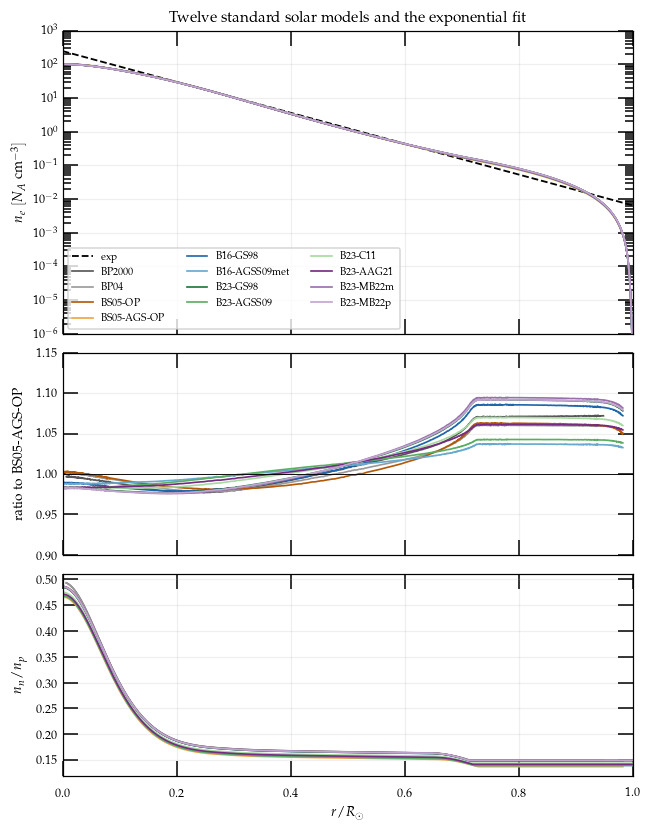

In [18]:
GENERATION = {'BP': ('#555555', '#999999'),
              'BS05': ('#b35806', '#f1a340'),
              'B16': ('#2166ac', '#67a9cf'),
              'B23': ('#1b7837', '#5aae61', '#a6dba0', '#762a83', '#9970ab', '#c2a5cf')}


def style(name):
    """One hue per generation of models, shades within it; the fit dashed and black."""
    if name == 'exp':
        return dict(color='k', ls='--', lw=1.2)
    gen = 'BP' if name.startswith('BP') else name.split('-')[0]
    members = [m for m in solarmodels.available_solar_models()
               if (m.startswith('BP') if gen == 'BP' else m.startswith(gen + '-'))]
    return dict(color=GENERATION[gen][members.index(name)], ls='-', lw=1.1)


LABEL = dict(fontsize=9)
fig, ax = plt.subplots(3, 1, figsize=(6.6, 8.2), sharex=True,
                       gridspec_kw=dict(height_ratios=[1.5, 1.0, 1.0], hspace=0.08))
per_cm3 = gd.N_AV*gd.UNIT_PER_CM3
ref_ne = solarmodels.electron_density_profile(MODEL)
for name in PROFILES:
    if name == 'exp':
        rr = np.linspace(0.0, 1.0, 400)
    else:
        rr = solarmodels.load_solar_model(name)['r_over_r_sun']   # the tabulated rows only
    xs = rr*L_SURFACE
    ne = np.asarray(ne_profile(name)(xs))
    ax[0].semilogy(rr, ne/per_cm3, label=name, **style(name))
    inside = rr <= solarmodels.solar_model_info(MODEL)['r_max']
    if name not in (MODEL, 'exp'):      # the fit's ratio runs off this scale; notebook 28 draws it
        ax[1].plot(rr[inside], ne[inside]/ref_ne(xs[inside]), **style(name))
    if name != 'exp':
        ax[2].plot(rr, ratio_profile(name)(xs), **style(name))
ax[0].set_ylabel(r'$n_e\ [N_A\ {\rm cm}^{-3}]$', **LABEL)
ax[0].set_ylim(1e-6, 1e3)
ax[0].legend(fontsize=6.8, ncol=3, loc='lower left')
ax[0].set_title('Twelve standard solar models and the exponential fit', fontsize=10)
ax[1].axhline(1.0, color='k', lw=0.6)
ax[1].set_ylim(0.9, 1.15)
ax[1].set_ylabel('ratio to %s' % MODEL, **LABEL)
ax[2].set_ylabel(r'$n_n/n_p$', **LABEL)
ax[2].set_xlabel(r'$r/R_\odot$', **LABEL)
ax[2].set_xlim(0.0, 1.0)
for a in ax:
    a.grid(True, alpha=0.2)
    a.tick_params(labelsize=8)
fig.align_ylabels(ax)
fig.savefig('../fig/solar_models_all_profiles.pdf', bbox_inches='tight')

spread of <P_ee> across the twelve tables: largest 2.4e-03, at 3.92 MeV (B23-AGSS09 high, BS05-OP low)
exponential fit minus BS05-AGS-OP: largest -0.098, at 2.61 MeV
six compositions within B23: largest spread 2.0e-04
one composition (GS98) across BS05, B16, B23: largest spread 2.3e-03
3+1 departure from 3nu: between -0.242 and -0.033 over the energies; the tables agree on it to 4.1e-03


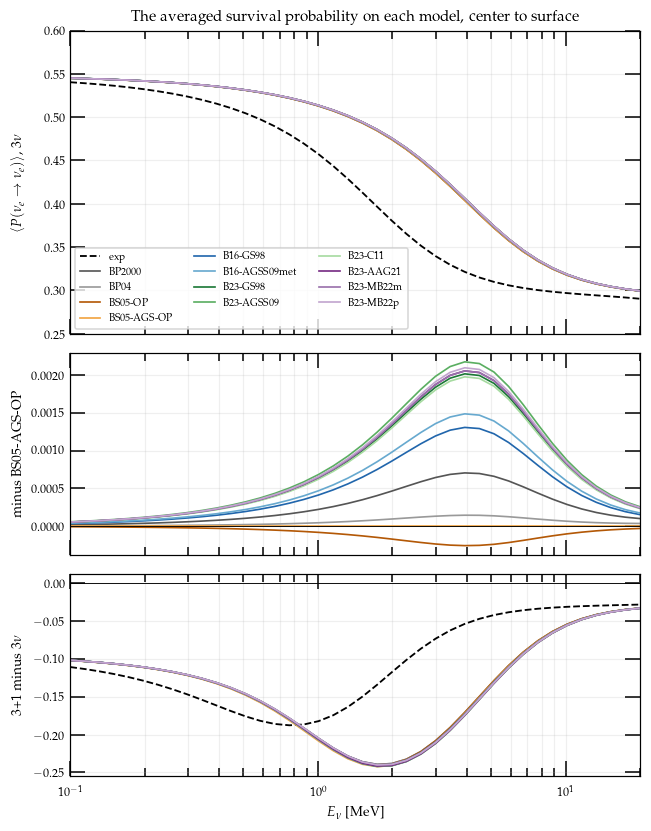

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(6.6, 8.2), sharex=True,
                       gridspec_kw=dict(height_ratios=[1.5, 1.0, 1.0], hspace=0.08))
e_mev = E_BSM/gd.UNIT_MEV
for name in PROFILES:
    ax[0].semilogx(e_mev, AVG[name]['P3'], label=name, **style(name))
    if name != 'exp':
        ax[1].semilogx(e_mev, AVG[name]['P3'] - AVG[MODEL]['P3'], **style(name))
    ax[2].semilogx(e_mev, AVG[name]['P4'] - AVG[name]['P3'], **style(name))
ax[0].set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$, $3\nu$', **LABEL)
ax[0].set_ylim(0.25, 0.6)
ax[0].legend(fontsize=6.8, ncol=3, loc='lower left')
ax[0].set_title('The averaged survival probability on each model, center to surface',
                fontsize=10)
ax[1].axhline(0.0, color='k', lw=0.6)
ax[1].set_ylabel('minus %s' % MODEL, **LABEL)
ax[2].axhline(0.0, color='k', lw=0.6)
ax[2].set_ylabel(r'3+1 minus $3\nu$', **LABEL)
ax[2].set_xlabel(r'$E_\nu$ [MeV]', **LABEL)
ax[2].set_xlim(e_mev[0], e_mev[-1])
for a in ax:
    a.grid(True, which='both', alpha=0.2)
    a.tick_params(labelsize=8)
fig.align_ylabels(ax)
fig.savefig('../fig/solar_models_all_probability.pdf', bbox_inches='tight')

tables = solarmodels.available_solar_models()
P3 = np.array([AVG[m]['P3'] for m in tables])
spread = P3.max(axis=0) - P3.min(axis=0)
i = int(np.argmax(spread))
print('spread of <P_ee> across the twelve tables: largest %.1e, at %.2f MeV (%s high, %s low)'
      % (spread[i], e_mev[i], tables[int(P3[:, i].argmax())], tables[int(P3[:, i].argmin())]))
d_exp = AVG['exp']['P3'] - AVG[MODEL]['P3']
j = int(np.argmax(np.abs(d_exp)))
print('exponential fit minus %s: largest %+.3f, at %.2f MeV' % (MODEL, d_exp[j], e_mev[j]))
b23 = np.array([AVG[m]['P3'] for m in tables if m.startswith('B23-')])
gs98 = np.array([AVG[m]['P3'] for m in ('BS05-OP', 'B16-GS98', 'B23-GS98')])
print('six compositions within B23: largest spread %.1e' % (b23.max(0) - b23.min(0)).max())
print('one composition (GS98) across BS05, B16, B23: largest spread %.1e'
      % (gs98.max(0) - gs98.min(0)).max())
ster = np.array([AVG[m]['P4'] - AVG[m]['P3'] for m in tables])
print('3+1 departure from 3nu: between %+.3f and %+.3f over the energies; the tables agree '
      'on it to %.1e' % (ster.min(), ster.max(), (ster.max(0) - ster.min(0)).max()))

**What the choice of model moves.** The twelve tables give the same averaged probability to
$2.4\times10^{-3}$, most where the curve is steepest, near 4 MeV; on the two plateaus they agree
far better. Most of that spread is between generations of models rather than between
compositions: the six B23 compositions agree to $2\times10^{-4}$, while BS05, B16 and B23 with
the same GS98 composition differ by $2.3\times10^{-3}$. The exponential fit is off by 0.1, forty
times the spread of the tables, for the reason notebook 28 gives: the average depends on the
density where the neutrino is born, and at the center the fit is 2.4 times too dense. The 3+1
state pulls the probability down by up to 0.24, and the tables agree about that to
$4\times10^{-3}$.

### Past the last row

The older tables stop short of the surface, and the curves above continued them along the
slope of their last interval. For a caller who would rather have no number than one computed
past the table, `stop_at_table_edge=True` returns NaN there, with a warning naming the edge.
How much the continuation moves the averaged observable is easy to check: stop at the edge
instead, and compare.

In [20]:
edge = solarmodels.table_edge('BP04')
kw = dict(nu_i=gd.NUE, nu_f=gd.NUE, density_profile='BP04', average=True)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    refused = oscprob.osc_prob_3nu_sun(E_BSM, L_SURFACE, 0.0, **OSC3_BSM,
                                       stop_at_table_edge=True, **kw)
print('BP04 to the surface, stop_at_table_edge=True: all NaN %s; warned %s'
      % (bool(np.all(np.isnan(refused))), sorted({w.category.__name__ for w in caught})))
at_edge = np.asarray(oscprob.osc_prob_3nu_sun(E_BSM, edge, 0.0, **OSC3_BSM, **kw))
print('BP04 continued to the surface minus BP04 stopped at its edge (%.3f R_sun): '
      'largest %.1e' % (edge/L_SURFACE, np.abs(AVG['BP04']['P3'] - at_edge).max()))

BP04 to the surface, stop_at_table_edge=True: all NaN True; warned ['SolarModelRangeWarning']


BP04 continued to the surface minus BP04 stopped at its edge (0.947 R_sun): largest 9.6e-05


---

**Previous:** [The strategy parameter](12_magnus_adiabatic_hybrid_strategy.ipynb)  
**Next:** [A supernova shock front](14_magnus_supernova_shock.ipynb) --- where the error stops being a phase and becomes an envelope  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Documentation](https://mbustama.github.io/Magnus/) &middot; [All notebooks](.)